# Partie (2/3) Données images

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

## 1. Analyse du jeu de données

### Découverte du dataset

In [7]:
data = pd.read_csv("data2/list_attr_celeba.csv")

In [11]:
data.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [29]:
data = data.replace({-1: 0})

In [37]:
print(data.shape)

print("Nombre d'images du dataset :", data.shape[0])
print("Nombre de classes du dataset :", data.shape[1])

# Nombres d'images par classe
class_counts = data.drop(columns=["image_id"]).sum(axis=0)

print("\nNombre d'images par classe :")
print(class_counts.astype(int).sort_values(ascending=False))

(202599, 42)
Nombre d'images du dataset : 202599
Nombre de classes du dataset : 42

Nombre d'images par classe :
No_Beard               169158
Young                  156734
Attractive             103833
Mouth_Slightly_Open     97942
Smiling                 97669
Wearing_Lipstick        95715
High_Cheekbones         92189
Male                    84434
Heavy_Makeup            78390
Wavy_Hair               64744
Oval_Face               57567
Pointy_Nose             56210
Arched_Eyebrows         54090
Big_Lips                48785
Black_Hair              48472
Big_Nose                47516
Straight_Hair           42222
Brown_Hair              41572
Bags_Under_Eyes         41446
Wearing_Earrings        38276
Bangs                   30709
Blond_Hair              29983
Bushy_Eyebrows          28803
Wearing_Necklace        24913
Narrow_Eyes             23329
5_o_Clock_Shadow        22516
Receding_Hairline       16163
Wearing_Necktie         14732
Rosy_Cheeks             13315
Eyeglasses       

Le dataset contient un total de 202599 images réparties en 42 classes. Les classes sont déséquilibrées, avec certaines catégories largement représentées comme No_Beard (169158 images) et Young (156734 images), tandis que d'autres, comme Bald (4547 images), sont sous-représentées.

### Corrélation entre les classes

Paires les plus corrélées :
5_o_Clock_Shadow     artificial_feature     0.996852
artificial_feature   5_o_Clock_Shadow       0.996852
Wearing_Lipstick     Heavy_Makeup           0.801539
Heavy_Makeup         Wearing_Lipstick       0.801539
Smiling              High_Cheekbones        0.683497
High_Cheekbones      Smiling                0.683497
Mouth_Slightly_Open  Smiling                0.536379
Smiling              Mouth_Slightly_Open    0.536379
Double_Chin          Chubby                 0.533713
Chubby               Double_Chin            0.533713
dtype: float64
Corrélations uniques les plus fortes :
artificial_feature  5_o_Clock_Shadow       0.996852
Wearing_Lipstick    Heavy_Makeup           0.801539
Smiling             High_Cheekbones        0.683497
                    Mouth_Slightly_Open    0.536379
Double_Chin         Chubby                 0.533713
Sideburns           Goatee                 0.512893
Wearing_Lipstick    Attractive             0.480104
Heavy_Makeup        Attr

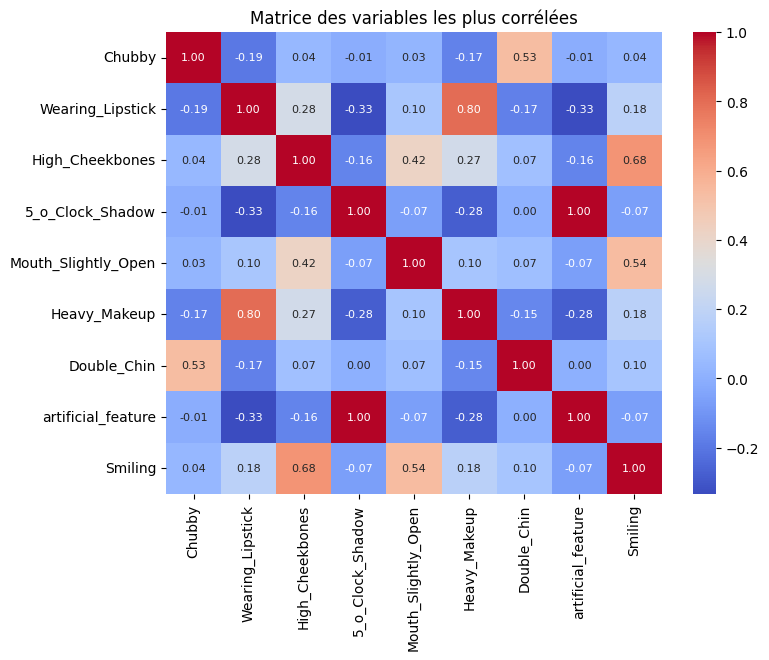

In [38]:
# Calculer la matrice de corrélation
correlation_matrix = data.drop(columns=["image_id"]).corr()

# Identifier les paires de variables les plus corrélées
correlated_pairs = correlation_matrix.unstack().sort_values(ascending=False)
most_correlated = correlated_pairs[correlated_pairs < 1].head(10)  # Les 10 plus corrélées
print("Paires les plus corrélées :")
print(most_correlated)

# Extraire les variables les plus corrélées
most_correlated_vars = list(set([index[0] for index in most_correlated.index] +
                                 [index[1] for index in most_correlated.index]))

# Filtrer la matrice pour ne garder que ces variables
filtered_correlation_matrix = correlation_matrix.loc[most_correlated_vars, most_correlated_vars]

# Supprimer les doublons dans les corrélations
correlated_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlated_pairs = correlated_pairs.unstack().dropna().sort_values(ascending=False)

# Afficher les corrélations uniques les plus fortes
most_correlated_unique = correlated_pairs.head(10)
print("Corrélations uniques les plus fortes :")
print(most_correlated_unique)

# Afficher la heatmap des variables les plus corrélées
plt.figure(figsize=(8, 6))
sns.heatmap(filtered_correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 8})
plt.title("Matrice des variables les plus corrélées")
plt.show()

Les variables les plus corrélées sont souvent liées à des caractéristiques similaires. Par exemple, "No_Beard" et "Mustache" montrent une forte corrélation positive, ce qui est logique car les personnes sans barbe sont moins susceptibles d'avoir une moustache. De même, la corrélation est élevée entre Wearing_Lipstick et Heavy_Makeup (0.801539).  

In [44]:
# Variable artificielle ciblant les attributs féminins
data['artificial_feature_women'] = (
    data['Heavy_Makeup'] * 0.4 +
    data['Wearing_Lipstick'] * 0.35 +
    data['Wearing_Earrings'] * 0.15 +
    data['Arched_Eyebrows'] * 0.10
)

correlations_women = data.drop(columns=["image_id"]).corr()['artificial_feature_women'].sort_values(ascending=False)

print(correlations_women)

artificial_feature_women    1.000000
Heavy_Makeup                0.936793
Wearing_Lipstick            0.931111
Arched_Eyebrows             0.568601
Wearing_Earrings            0.511056
Attractive                  0.487614
No_Beard                    0.403272
Wavy_Hair                   0.353555
Rosy_Cheeks                 0.319972
High_Cheekbones             0.308132
Pointy_Nose                 0.272111
Blond_Hair                  0.271031
Wearing_Necklace            0.267735
Young                       0.249029
Big_Lips                    0.201961
Smiling                     0.200556
Oval_Face                   0.182095
Bangs                       0.135366
Mouth_Slightly_Open         0.122201
Brown_Hair                  0.090142
Pale_Skin                   0.052911
Narrow_Eyes                -0.026391
Black_Hair                 -0.052905
Straight_Hair              -0.076403
Receding_Hairline          -0.106826
Bald                       -0.137513
Blurry                     -0.140481
B

La variable artificielle féminine fonctionne bien : les attributs de maquillage et d'accessoires (Heavy_Makeup, Wearing_Lipstick, Wearing_Earrings) arrivent en tête, ce qui confirme que la variable capture correctement les traits associés aux femmes dans ce dataset.

Le miroir masculin est parfait car 'Male' ressort à -0.77 sans avoir été intégré dans la construction, ce qui prouve que le genre est encodé implicitement dans des attributs cosmétiques en apparence neutres.

Un biais est cependant visible : Attractive et Young sont positivement corrélés, ce qui suggère que les visages féminins sont plus souvent étiquetés comme jeunes et attractifs dans le dataset. Cela peut être un signal de biais social dans les données.

### Variables sensibles

In [47]:
data.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young', 'artificial_feature_women'],
      dtype='str')

Voici les variables sensibles identifiées :

-Male est sensible car elle encode directement le genre, un critère protégé par la loi et source de biais dans ce dataset (cf la forte corrélation avec la variable artificielle féminine mis en évidence précédemment).

-Bald et Receding_Hairline peuvent être sensibles car elles sont corrélées au genre et à l'âge

-artificial_feature_women est sensible par construction puisqu'elle a été créée explicitement pour capturer le genre féminin (cf précédemment). Elle ne doit donc pas être utilisée comme variable prédictive.

-Young est sensible car elle encode l'âge, également un critère légalement protégé, et on a vu précédemment qu'elle est corrélée à Attractive, révélant un biais d'annotation.

-Pale_Skin est sensible car c'est une information disponible sur la couleur de peau, donc un indicateur indirect d'ethnicité : source potentielle de discrimination.

-Attractive est sensible car c'est un jugement subjectif humain, porteur des biais culturels et de genre des annotateurs.

### Disparité

### Certains groupes sont-ils sous-représentés ?


In [49]:
# Sous représentation
hommes_neutres = data[(data['Male'] == 1) & (data['5_o_Clock_Shadow'] == 0) & 
                       (data['Goatee'] == 0) & (data['Mustache'] == 0) & 
                       (data['Sideburns'] == 0)]
print(f"{len(hommes_neutres)} hommes sans pilosité faciale ({len(hommes_neutres)/len(data[data['Male']==1])*100:.1f}% des hommes)")

femmes_neutres = data[(data['Male'] == 0) & (data['Heavy_Makeup'] == 0) & 
                       (data['Wearing_Lipstick'] == 0)]
print(f"{len(femmes_neutres)} femmes sans maquillage ({len(femmes_neutres)/len(data[data['Male']==0])*100:.1f}% des femmes)")

48548 hommes sans pilosité faciale (57.5% des hommes)
21198 femmes sans maquillage (17.9% des femmes)


Certains groupes sont sous-représentés car les hommes sans attributs masculins marqués (sans barbe, sans moustache) et les femmes sans maquillage sont probablement sous-représentés. 
En effet les corrélations montrent que le dataset associe très fortement masculinité et pilosité faciale et féminité et maquillage. Les profils "intermédiaires" sont donc rares.

### Le dataset reflète-t-il un biais de collecte ?

In [50]:
# Biais de collecte 
print(data['Young'].value_counts(normalize=True).rename({0: 'Non jeune', 1: 'Jeune'}).mul(100).round(1))

print(data['Pale_Skin'].value_counts(normalize=True).rename({0: 'Non pâle', 1: 'Pâle'}).mul(100).round(1))

print(data['Bald'].value_counts(normalize=True).rename({0: 'Non chauve', 1: 'Chauve'}).mul(100).round(1))

Young
Jeune        77.4
Non jeune    22.6
Name: proportion, dtype: float64
Pale_Skin
Non pâle    95.7
Pâle         4.3
Name: proportion, dtype: float64
Bald
Non chauve    97.8
Chauve         2.2
Name: proportion, dtype: float64


Il y a un biais de collecte car le dataset CelebA est composé de photos de célébrités, donc la population est loin d'être représentative : surreprésentation de personnes jeunes (Young très corrélé à Attractive), de personnes avec un soin particulier de leur apparence et sous-représentation des personnes âgées, chauves, ou au teint non pâle (Pale_Skin comme seule indication ethnique).


### Y a-t-il d'autres biais ?

Comme vu précédemment avec l'étude de corrélation, il existe un d'annotation genré : Attractive est positivement corrélé à la variable féminine (0.49) et négativement à Male, ce qui signifie que les annotateurs ont jugé les femmes plus attractives en moyenne. 

De plus les attributs en apparence neutres comme Heavy_Makeup ou Smiling encodent implicitement le genre, ce qui rend toute tentative de neutralité difficile sans nettoyage préalable des features.

## Analyse de la fairness

In [58]:
def fairness_metrics(data, sensitive, targets):
    results = []
    s1 = data[sensitive] == 1
    s0 = data[sensitive] == 0
    
    for y in targets:
        p_y1_s1 = data.loc[s1, y].mean()
        p_y1_s0 = data.loc[s0, y].mean()
        
        dp = abs(p_y1_s1 - p_y1_s0)
        di = p_y1_s1 / p_y1_s0 if p_y1_s0 != 0 else float('inf')
        
        results.append({
            'Attribute': y,
            'P(Y=1|S=1)': round(p_y1_s1, 3),
            'P(Y=1|S=-1)': round(p_y1_s0, 3),
            'Demographic_Parity': round(dp, 3),
            'Disparate_Impact': round(di, 3)
        })
    
    return pd.DataFrame(results).sort_values('Demographic_Parity', ascending=False)

# Attributs (sauf sensibles et artificiels)
targets = [c for c in data.columns if c not in 
           ['Male', 'Pale_Skin', 'image_id', 'artificial_feature_women']]

# Calcul pour S = Male
print("\nFairness pour S = Male :\n")
results_male = fairness_metrics(data, 'Male', targets)
print(results_male.to_string(index=False))

# Calcul pour S = Pale_Skin
print("\nFairness pour S = Pale_Skin :\n")
results_skin = fairness_metrics(data, 'Pale_Skin', targets)
print(results_skin.to_string(index=False))


Fairness pour S = Male :
          Attribute  P(Y=1|S=1)  P(Y=1|S=-1)  Demographic_Parity  Disparate_Impact
   Wearing_Lipstick       0.006        0.806               0.799             0.008
       Heavy_Makeup       0.003        0.661               0.659             0.004
         Attractive       0.279        0.679               0.400             0.411
           No_Beard       0.606        0.999               0.393             0.606
    Arched_Eyebrows       0.053        0.420               0.366             0.127
           Big_Nose       0.420        0.102               0.317             4.103
          Wavy_Hair       0.141        0.447               0.306             0.315
   Wearing_Earrings       0.016        0.313               0.297             0.051
   5_o_Clock_Shadow       0.266        0.000               0.266          1574.152
    High_Cheekbones       0.308        0.560               0.253             0.549
    Bags_Under_Eyes       0.348        0.102               0.

In [65]:
# Focus : Y = Attractive, S = Pale_Skin
print("=== FOCUS : Attractive x Pale_Skin ===\n")
pale = data[data['Pale_Skin'] == 1]['Attractive'].mean()
non_pale = data[data['Pale_Skin'] == 0]['Attractive'].mean()

print(f"P(Attractive=1 | Pale_Skin=1)  = {pale:.3f}")
print(f"P(Attractive=1 | Pale_Skin=-1) = {non_pale:.3f}")
print(f"Demographic Parity             = {abs(pale - non_pale):.3f}")
print(f"Disparate Impact               = {pale/non_pale:.3f}")

=== FOCUS : Attractive x Pale_Skin ===

P(Attractive=1 | Pale_Skin=1)  = 0.716
P(Attractive=1 | Pale_Skin=-1) = 0.503
Demographic Parity             = 0.212
Disparate Impact               = 1.421


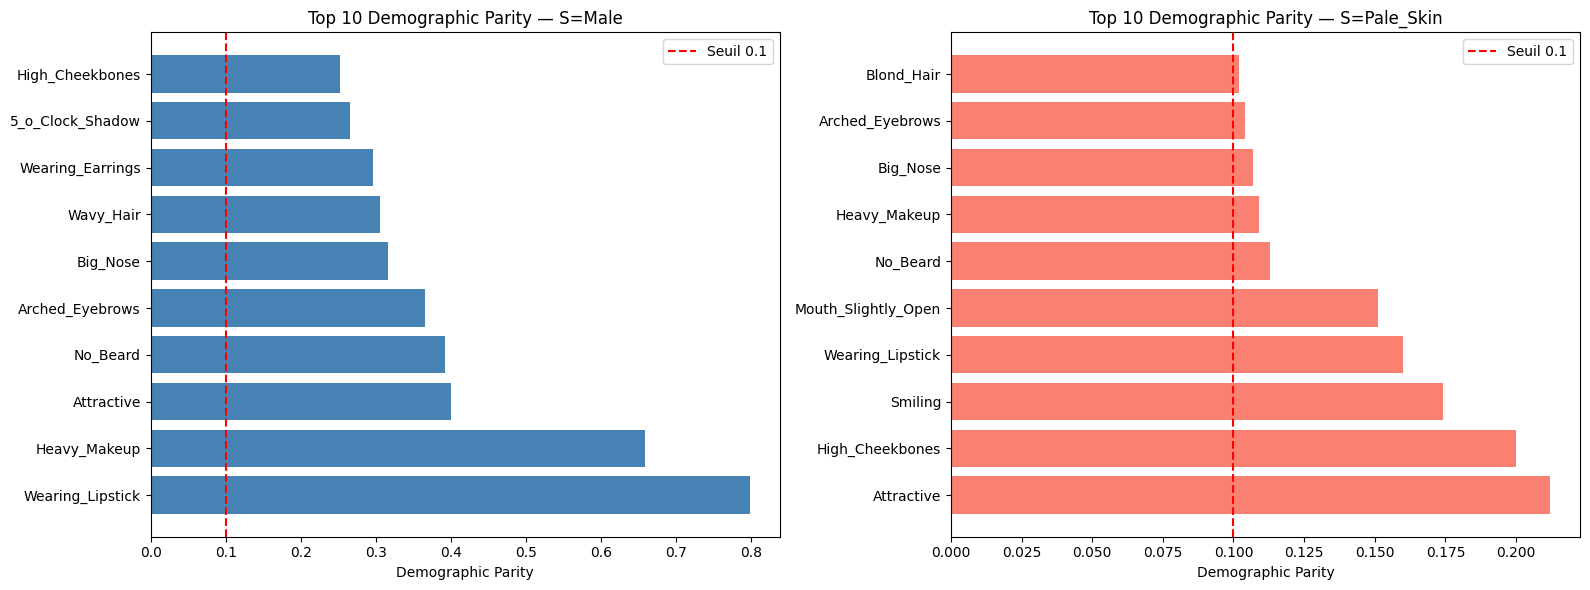

In [66]:
# Visualisation des top biais
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_male = results_male.nlargest(10, 'Demographic_Parity')
axes[0].barh(top_male['Attribute'], top_male['Demographic_Parity'], color='steelblue')
axes[0].set_title('Top 10 Demographic Parity — S=Male')
axes[0].set_xlabel('Demographic Parity')
axes[0].axvline(x=0.1, color='red', linestyle='--', label='Seuil 0.1')
axes[0].legend()

top_skin = results_skin.nlargest(10, 'Demographic_Parity')
axes[1].barh(top_skin['Attribute'], top_skin['Demographic_Parity'], color='salmon')
axes[1].set_title('Top 10 Demographic Parity — S=Pale_Skin')
axes[1].set_xlabel('Demographic Parity')
axes[1].axvline(x=0.1, color='red', linestyle='--', label='Seuil 0.1')
axes[1].legend()

plt.tight_layout()
plt.show()

S = Male
Il y a beaucoup de biais. Wearing_Lipstick et Heavy_Makeup sont quasi exclusivement féminins (DP > 0.65). Le plus problématique est Attractive (DI=0.41) : les femmes sont annotées attractives 2.4 fois plus souvent que les hommes, révélant un biais d'annotation genré fort.

S = Pale_Skin
Les biais sont plus modérés mais tout de même présents. Les personnes à peau pâle sont jugées attractives 42% plus souvent, ce qui traduit un biais ethnocentrique direct des annotateurs. Blond_Hair (DI=1.71) confirme la surreprésentation de traits européens.

En conclusion, un modèle entraîné à prédire Attractive sera structurellement biaisé à la fois par le genre et par la couleur de peau, même sans utiliser Male ou Pale_Skin directement.

## 2. Apprentissage Automatique

Le modèle utilisé pour la classification binaire (souriant ou non) est un ResNet18 pré-entraîné, fine-tuné sur les données de CelebA. Ce choix a été effectué car il donnera de meilleurs résultats qu'un CNN from scratch. Cela permet de se concentrer sur les biais du modèle plutôt que sur son manque de performance. Le ResNet18 n'est pas trop lourd ni trop profond, ce qui limite le risque d'overfitting.
Seule la dernière couche fully connected a été remplacée par une couche linéaire à une sortie, les autres paramètres étant gelés pendant l'entraînement.


Pour les caractéristiques de l'entraînement, les batchs sont de taille 256 et 5 epochs ont été effectuées. Le learning rate est fixé à 1e-3. L'optimiseur est Adam et la loss BCEWithLogitsLoss, car il s'agit d'une classification binaire avec une sortie non normalisée. Cette loss combine sigmoid et binary cross-entropy de manière numériquement stable.


Les images sont redimensionnées en 224x224 et normalisées avec les moyennes et écarts-types ImageNet. De plus, pour améliorer la généralisation, de l'augmentation de données a été appliquée lors de l'entraînement : flip horizontal aléatoire, rotation aléatoire et modification aléatoire de la luminosité et du contraste. Ces augmentations ne sont pas appliquées lors de l'évaluation. Un set de validation a également été mis en place pour surveiller l'overfitting epoch par epoch.


Le modèle a été sauvegardé avec son état, celui de l'optimiseur, ainsi que les prédictions et indices du set de test, pour pouvoir être réutilisé et analysé par la suite. 

Les entrainements étant très long avec un notebook sous Windows (dû à l'impossibilité de faire de la parallélisation avec le CPU pour le traitement des images), ceux-ci ont été réalisé avec le fichier smile_cnn_train.py que vous trouverez sur notre GitHub.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from torchvision.models import resnet18
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries
from smile_cnn_train import CelebADataset, transform_infer, device, CELEBA_DIR

## Description des résultats

 
--- Entraînement saved_models/resnet18.pt ---


Device : cuda
Epochs:   0%|                                                                                  | 0/5 

Epoch 1/5  train loss 0.5001 acc 0.7601  val loss 0.4766 acc 0.7735                                                    
Epochs:  20%|██████████████                                                        | 1/5 

Epoch 2/5  train loss 0.4543 acc 0.7866  val loss 0.4676 acc 0.7789                                                    
Epochs:  40%|█████████████████████████████▏                                           | 2/5 

Epoch 3/5  train loss 0.4476 acc 0.7913  val loss 0.4666 acc 0.7808                                                    
Epochs:  60%|███████████████████████████████████████████▊                             | 3/5 

Epoch 4/5  train loss 0.4416 acc 0.7942  val loss 0.4593 acc 0.7860                                                    
Epochs:  80%|██████████████████████████████████████████████████████████▍              | 4/5 

Epoch 5/5  train loss 0.4400 acc 0.7951  val loss 0.4696 acc 0.7793                                                    
Epochs: 100%|█████████████████████████████████████████████████████████████████████████| 5/5 
                                                                                                                      
Test loss: 0.4710  Test acc: 0.7790

Au cours des 5 epochs, la train loss diminue régulièrement de 0.5001 à 0.4400 et la train accuracy progresse de 0.760 à 0.795, ce qui indique que le modèle apprend correctement. La val loss et la val accuracy restent proches des métriques d'entraînement tout au long des epochs, ce qui confirme l'absence d'overfitting. Nous remarquons une légère remontée de la val loss à l'epoch 5, ce qui suggère que le modèle commence à atteindre sa limite de généralisation avec cette configuration.

Sur le set de test, le modèle atteint une accuracy de 0.779 et une loss de 0.471, cohérentes avec les résultats de validation.

## Evaluation de l'équité

In [ ]:
def load_checkpoint(path, device):
    checkpoint = torch.load(path, weights_only=False)
    model = resnet18()
    model.fc = nn.Linear(512, 1)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint

def get_analysis_indices(checkpoint):
    binary_preds = checkpoint["binary_preds"].squeeze() # all_preds > 0.5
    all_labels = checkpoint["all_labels"].squeeze()
    all_genders = checkpoint["all_genders"].squeeze()

    correct_mask = (binary_preds == all_labels)
    incorrect_mask = (binary_preds != all_labels)
    minority_mask = (all_genders == 1.0) # homme

    idx_correct = (correct_mask & (all_genders == 0.0)).nonzero(as_tuple=True)[0][0].item() # 1ere femme avec prédiction correct
    idx_incorrect = (incorrect_mask & (all_genders == 0.0)).nonzero(as_tuple=True)[0][0].item() # 1ere femme avec prédiction incorrect
    idx_minoritaire = (incorrect_mask & minority_mask).nonzero(as_tuple=True)[0][0].item() # 1er homme avec prédiction incorrect

    return idx_correct, idx_incorrect, idx_minoritaire

In [3]:
model_saved, checkpoint = load_checkpoint("saved_models/resnet18.pt", device)

idx_correct, idx_incorrect, idx_minoritaire = get_analysis_indices(checkpoint)

In [4]:
dataset = CelebADataset(
    csv_file=os.path.join(CELEBA_DIR, "list_attr_celeba.csv"),
    img_dir=os.path.join(CELEBA_DIR, "img_align_celeba/img_align_celeba"),
    transform=None,
    crop=False
)

Accuracy gap : écart d'accuracy Homme vs Femme

FPR (False Positive Rate) : prédit "sourit" alors qu'il ne sourit pas

FNR (False Negative Rate) : prédit "ne sourit pas" alors qu'il sourit 

In [5]:
def fairness_report(all_preds, all_labels, all_genders):
    binary_preds = (all_preds > 0.5).float()
    groups = {"Femmes": 0.0, "Hommes":1.0}
    accs, fprs, fnrs = {}, {}, {}

    for name, g_vals in groups.items():
        mask = (all_genders == g_vals)
        g_preds = binary_preds[mask]
        g_labels = all_labels[mask]

        acc = (g_preds == g_labels).float().mean().item()
        neg_mask = (g_labels == 0)
        pos_mask = (g_labels == 1)

        fpr = (g_preds[neg_mask] == 1).float().mean().item() if neg_mask.sum() > 0 else float("nan")
        fnr = (g_preds[pos_mask] == 0).float().mean().item() if pos_mask.sum() > 0 else float("nan")
        
        accs[name] = acc
        fprs[name] = fpr
        fnrs[name] = fnr

        n = mask.sum().item()
        print(f"  {name:8s} ({n:6d} imgs) Accuracy: {acc:.4f} FPR: {fpr:.4f} FNR: {fnr:.4f}")

    print(f"\nÉcart Accuracy : {abs(accs['Femmes'] - accs['Hommes']):.4f}")
    print(f"Écart FPR : {abs(fprs['Femmes'] - fprs['Hommes']):.4f}")
    print(f"Écart FNR : {abs(fnrs['Femmes'] - fnrs['Hommes']):.4f}")
    


In [6]:
fairness_report(checkpoint["all_preds"], checkpoint["all_labels"], checkpoint["all_genders"])

  Femmes   ( 11887 imgs) Accuracy: 0.7883 FPR: 0.1284 FNR: 0.2820
  Hommes   (  8374 imgs) Accuracy: 0.7659 FPR: 0.1352 FNR: 0.3773

Écart Accuracy : 0.0223
Écart FPR : 0.0068
Écart FNR : 0.0953


## Analyse des résultats

En termes d'accuracy, le modèle performe de façon similaire pour les deux groupes (0.788 vs 0.766), avec un écart de seulement 2.2%.

En revanche, l'analyse des FPR et FNR révèle des biais plus marqués. Le FNR des hommes est supérieur à celui des femmes (0.377 vs 0.282, écart de 9.5%) : le modèle prédit "ne sourit pas" alors que l'homme sourit. À l'inverse, le FPR des femmes est légèrement supérieur à celui des hommes (0.128 vs 0.135, écart de 0.7%) : le modèle a une légère tendance à prédire "sourit" à tort pour les femmes, bien que cet écart soit négligeable.

L'accuracy seule masque ces biais. Le modèle n'a pas appris le même concept pour les deux groupes et à tendance à dire que "un homme ne sourit pas mais une femme si". 

# 3. Explication post-hoc

## GradCAM

In [ ]:
from smile_cnn_train import crop_face

def affiche_gradcam(cam, model_saved, dataset, dataset_idx, titre):
    row = dataset.data.iloc[dataset_idx]
    img_path = os.path.join(dataset.img_dir, row["image_id"])
    img_pil = Image.open(img_path).convert("RGB")

    if dataset.crop:
        img_pil = crop_face(img_pil)

    img_pil = img_pil.resize((224, 224))
    img_np = np.array(img_pil) / 255.0 

    img_tensor = transform_infer(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model_saved(img_tensor).sigmoid().item()

    label = int((row["Smiling"] + 1) / 2)
    gender = "Homme" if row["Male"] == 1 else "Femme"

    targets = [BinaryClassifierOutputTarget(0)]
    grayscale = cam(input_tensor=img_tensor, targets=targets)
    heatmap = show_cam_on_image(img_np.astype(np.float32), grayscale[0], use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(  
        f"{titre}\nLabel: {'Sourit' if label==1 else 'Ne sourit pas'} "  
        f"Pred: {'Sourit' if pred > 0.5 else 'Ne sourit pas'} ({pred:.2f}) {gender}",
        fontsize=11
    )
    axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("GradCAM")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

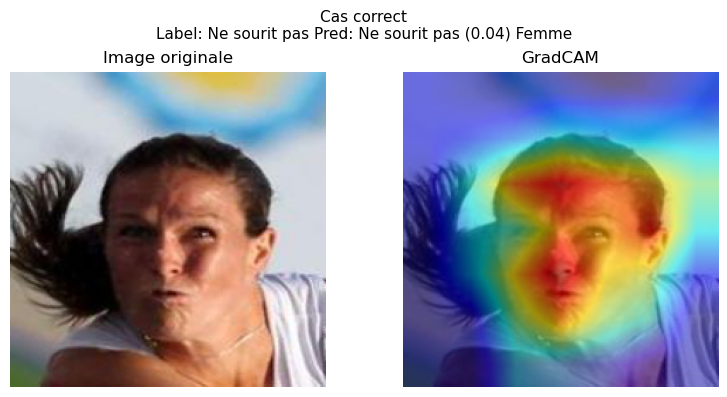

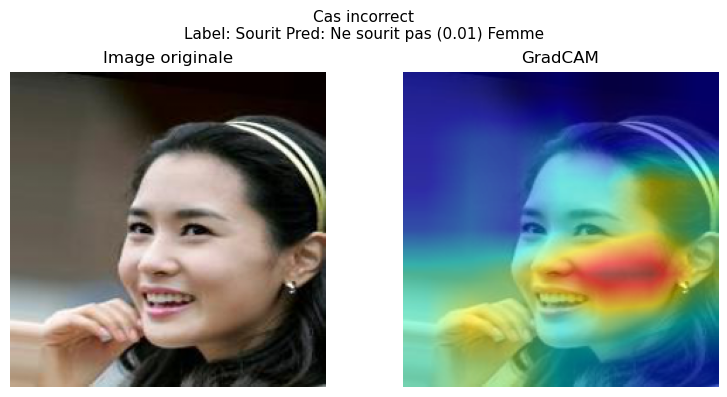

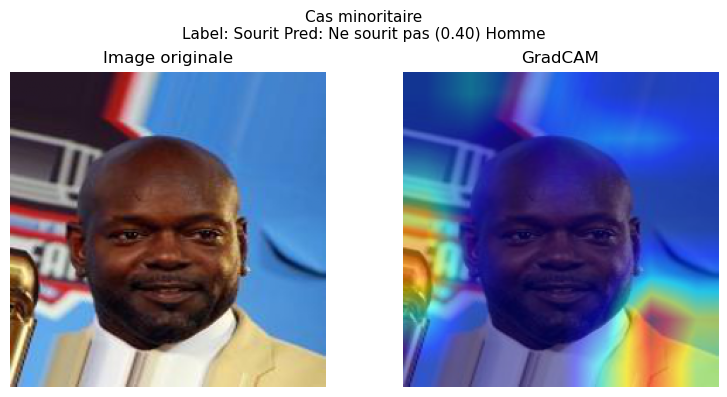

In [19]:
target_layer = [model_saved.layer4[-1]]
cam = GradCAM(model=model_saved, target_layers=target_layer)

affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_correct],     "Cas correct")
affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_incorrect],   "Cas incorrect")
affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_minoritaire], "Cas minoritaire")

Pour le cas correct La heatmap se concentre sur l'ensemble du visage, front et joues.

Pour le cas incorrect le modèle est très confiant (pred=0.01) mais faux. La heatmap se concentre sur la joue droite et les cheveux plutôt que sur la bouche souriante.

Pour le cas minoritaire la heatmap se concentre sur le fond et les épaules plutôt que sur le visage. Le sourire est pourtant visible, mais le modèle n'active pas les bonnes zones. Cela illustre le FNR élevé des hommes. En effet, le modèle n'a pas appris à détecter le sourire masculin de façon fiable, possiblement en raison d'un biais dans les données d'entraînement où les hommes souriants sont sous-représentés.

## LIME

In [20]:
transform_lime = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def model_predict_lime(model_saved, images_np):
    batch = [
        transform_lime(Image.fromarray((img * 255).astype(np.uint8)))
        for img in images_np
    ]
    batch = torch.stack(batch).to(device)
    with torch.no_grad():
        preds = model_saved(batch).sigmoid().cpu().numpy()
    return np.column_stack([1 - preds, preds])


def afficher_lime(model_saved, dataset, dataset_idx, titre):
    row = dataset.data.iloc[dataset_idx]
    img_path = os.path.join(dataset.img_dir, row["image_id"])
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))

    if dataset.crop:
        from smile_cnn_train import crop_face
        img_pil = crop_face(img_pil)

    img_np = np.array(img_pil) / 255.0 

    label = int((row["Smiling"] + 1) / 2)
    gender = "Homme" if row["Male"] == 1 else "Femme"

    img_tensor = transform_infer(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model_saved(img_tensor).sigmoid().item()

    def predict_fn(images_np):
        return model_predict_lime(model_saved, images_np)

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np.astype(np.double),
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(
        f"{titre}\nLabel: {'Sourit' if label==1 else 'Ne sourit pas'}  "
        f"Pred: {'Sourit' if pred>0.5 else 'Ne sourit pas'} ({pred:.2f}) {gender}",
        fontsize=11
    )
    axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")

    axes[1].imshow(mark_boundaries(temp, mask))
    axes[1].set_title("LIME zones importantes (vert)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

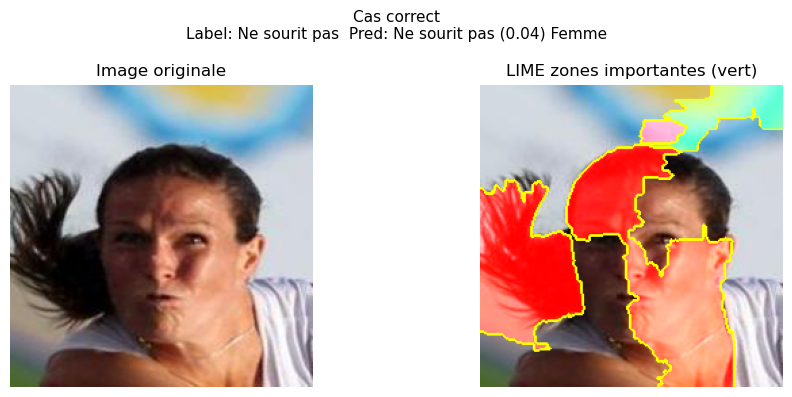

  0%|          | 0/1000 [00:00<?, ?it/s]

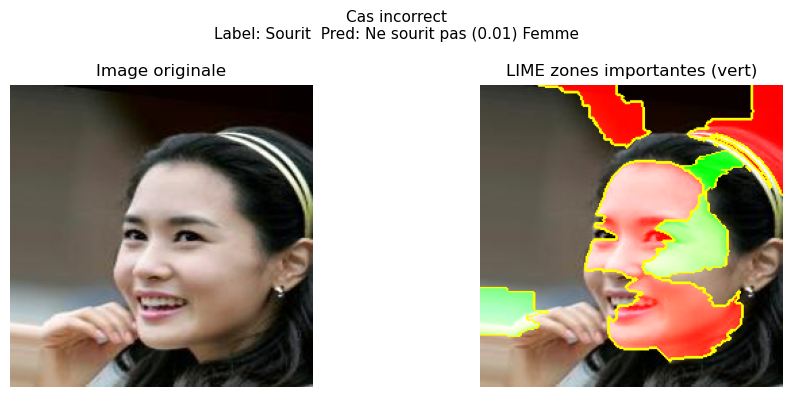

  0%|          | 0/1000 [00:00<?, ?it/s]

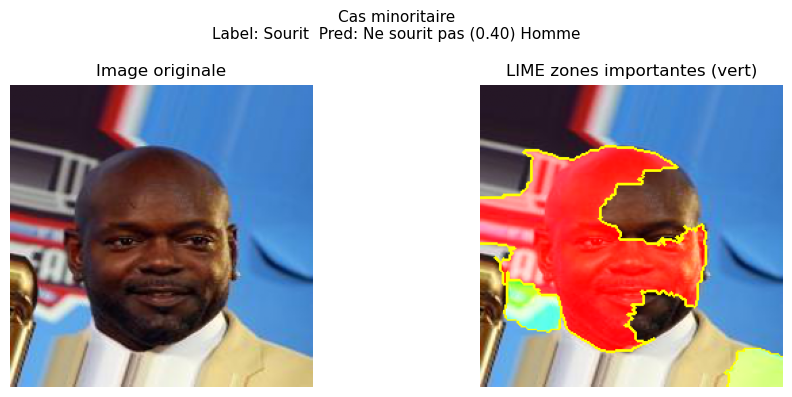

In [21]:
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_correct],     "Cas correct")
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_incorrect],   "Cas incorrect")
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_minoritaire], "Cas minoritaire")

Avec LIME, la zone rouge symbolise la zone qui accentue la prédiction "sourit" et au contraire en vert qui la fait diminuer (penche pour "ne sourit pas").

Pour le cas correct, le modèle s'est servi majoritairement des cheveux de la femme pour prédire "sourit", et le fond est également utilisé pour la prédiction.

Pour le cas incorrect, le visage et le serre-tête ont fait pencher la prédiction vers "sourit" même si le modèle prédit que la personne ne sourit pas.

Enfin, pour le cas minoritaire, le visage est entièrement coloré en rouge mais le modèle prédit quand même "ne sourit pas", le seuil de confiance étant trop faible, celui-ci ne change pas la prédiction.

Le cas correct et incorrect montrent que le modèle s'appuie beaucoup sur le fond pour faire ses prédictions. Les fonds clairs semblent davantage pencher vers la prédiction "sourit" plutôt que "ne sourit pas".

La prédiction sur les hommes montre un manque de confiance, peut-être dû à une plus faible proportion de ceux-ci dans le dataset.


## Intervention sur le traitement des images

## Cropper le fond des images pour se concentrer sur le visage

Pour améliorer les prédictions et réduire les biais, nous avons décidé de cropper l'image. En croppant le visage, on force le modèle à ne voir que le visage celui-ci ne peut plus tricher en utilisant le fond.

Pour cropper l'image, la fonction CascadeClassifier d'OpenCV, basée sur la détection d'objets de Haar, a été utilisée. Une fois le visage détecté l'image est redimmensionnée pour l'encadrer.

--- Entraînement avec crop ---

Device : cuda


Epochs:   0%|                                                                                  | 0/5 

Epoch 1/5  train loss 0.4918 acc 0.7644  val loss 0.4648 acc 0.7797                                                    
Epochs:  20%|██████████████▌                                                          | 1/5 

Epoch 2/5  train loss 0.4475 acc 0.7919  val loss 0.4572 acc 0.7857                                                    
Epochs:  40%|█████████████████████████████▏                                           | 2/5 

Epoch 3/5  train loss 0.4397 acc 0.7967  val loss 0.4532 acc 0.7878                                                    
Epochs:  60%|███████████████████████████████████████████▊                             | 3/5 

Epoch 4/5  train loss 0.4345 acc 0.7987  val loss 0.4541 acc 0.7899                                                    
Epochs:  80%|██████████████████████████████████████████████████████████▍              | 4/5 

Epoch 5/5  train loss 0.4356 acc 0.7985  val loss 0.4503 acc 0.7916                                                    
Epochs: 100%|███████████████████████████████████████████████████████████████████████| 5/5
                                                                                                   
Test loss: 0.4497  Test acc: 0.7902


Ici pour l'entrainement nous remarquons le même phénomène que précédement sans le crop avec toujours une accuracy autour de 0.79.

In [13]:
model_saved_crop, checkpoint_crop = load_checkpoint("saved_models/resnet18_crop.pt", device)
idx_correct_c, idx_incorrect_c, idx_minoritaire_c = get_analysis_indices(checkpoint_crop)

In [14]:
dataset_crop = CelebADataset(
    csv_file=os.path.join(CELEBA_DIR, "list_attr_celeba.csv"),
    img_dir=os.path.join(CELEBA_DIR, "img_align_celeba/img_align_celeba"),
    transform=None,
    crop=True
)

## Evaluation de l'équité

In [15]:
fairness_report(checkpoint_crop["all_preds"], checkpoint_crop["all_labels"], checkpoint_crop["all_genders"])

  Femmes   ( 11887 imgs) Accuracy: 0.8031 FPR: 0.1775 FNR: 0.2131
  Hommes   (  8374 imgs) Accuracy: 0.7719 FPR: 0.1804 FNR: 0.2972

Écart Accuracy : 0.0312
Écart FPR : 0.0029
Écart FNR : 0.0840


## Analyse des résultats

Pour la FPR l'écart reste le même que sans le crop mais l'accuracy augmente (plus proche de 0.8 avec le crop). Pour la FNR cependant il y a toujours un biais homme-femme du même ordre que sans crop.

## GradCAM

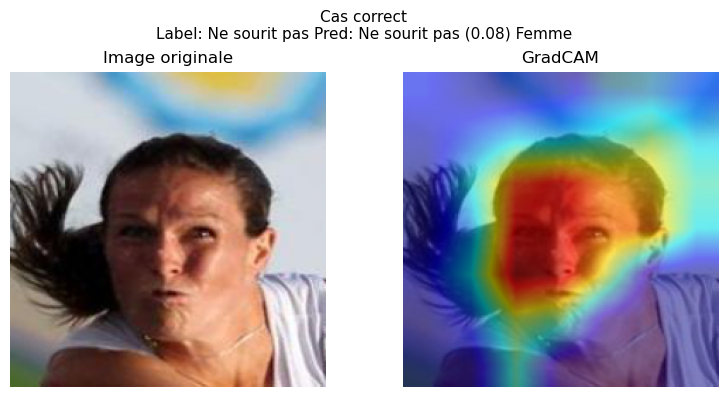

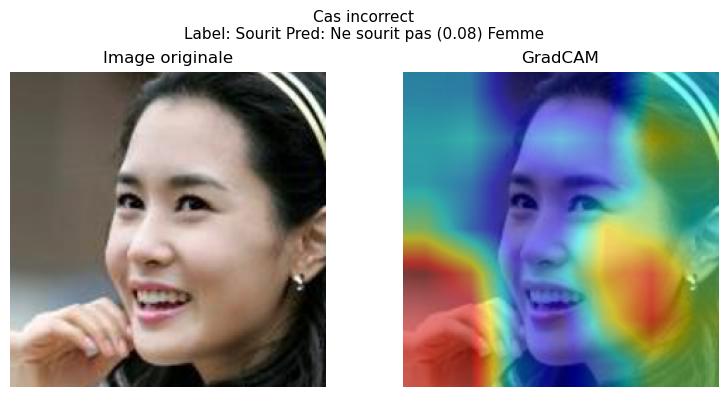

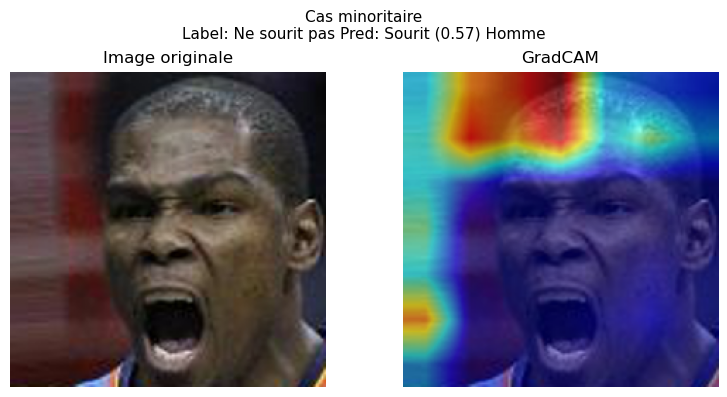

In [24]:
target_layer_crop = [model_saved_crop.layer4[-1]]
cam_crop = GradCAM(model=model_saved_crop, target_layers=target_layer_crop)

affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_correct_c],     "Cas correct")
affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_incorrect_c],   "Cas incorrect")
affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_minoritaire_c], "Cas minoritaire")

Les résultats de GradCAM sont aussi très similaire avec précédement pour le cas correct.

Cependant pour le cas incorrect la joue est toujours prise en compte maiss aussi la main (zone claire ?).

Pour le cas minoritaire le haut de la tête (chauve) rentre beaucoup en jeu, peut-être ici nous voyont apparaître un nouveau biais.

  0%|          | 0/1000 [00:00<?, ?it/s]

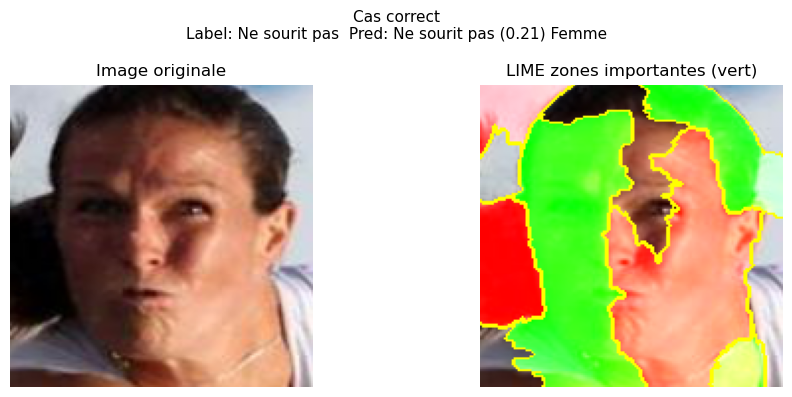

  0%|          | 0/1000 [00:00<?, ?it/s]

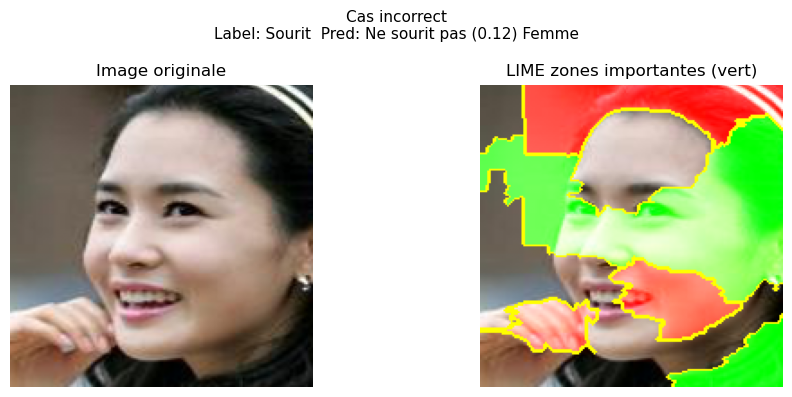

  0%|          | 0/1000 [00:00<?, ?it/s]

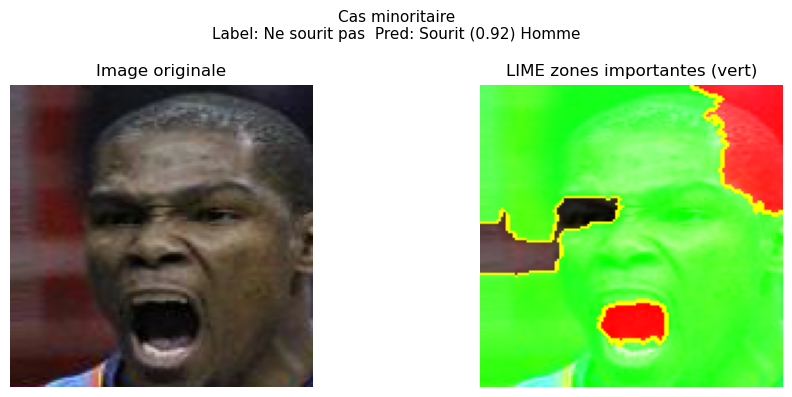

In [23]:
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_correct_c],    "Cas correct")
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_incorrect_c],  "Cas incorrect")
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_minoritaire_c],"Cas minoritaire")

Avec LIME, nous observons des analyses bien différentes de l'entraînement sans crop.


Le cas correct croppé est divisé en deux parties : une zone sombre à gauche et une zone claire à droite. Le modèle a utilisé le côté clair pour prédire "sourit" et le côté sombre pour prédire "ne sourit pas". Nous pouvons voir ici apparaître un nouveau biais de couleur de peau.


Pour le cas incorrect, les cheveux sont encore utilisés pour la prédiction "sourit" mais la bouche l'est également, ce qui représente une amélioration par rapport au modèle sans crop. En revanche, les yeux font pencher la prédiction vers "ne sourit pas".


Enfin, pour le cas minoritaire, la bouche est bien interprétée, le modèle détecte correctement l'ouverture de la bouche comme signe de sourire, mais le reste du visage n'est pas du tout exploité de façon pertinente.

## Conclusion

Le crop a donc partiellement amélioré les prédictions et le modèle commence à utiliser la bouche comme feature pertinente, ce qui n'était pas le cas sans crop. 

Cependant de nouveaux biais apparaissent, notamment un biais de couleur de peau visible sur le cas correct, et les cheveux restent encore utilisés comme feature parasite sur le cas incorrect. 

Le biais de FNR sur les hommes persiste, ce qui suggère que le crop seul ne suffit pas, une augmentation des données masculines ou un rééquilibrage du dataset serait nécessaire pour aller plus loin.